In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random as rn

In [ ]:
from pathlib import Path
from google.colab import drive
import os
import cv2
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical

# Introduction to Deep Learning
Deep learning is a subset of machine learning that mimics the workings of the human brain to process data and create patterns for decision-making. It is used in applications such as image recognition, natural language processing, and more.


# **Important !!!!!**
### Check that the gpu is connected

In [ ]:
import tensorflow as tf

device_name = tf.test.gpu_device_name()
if "GPU" not in device_name:
    print("GPU device not found")

print('Found GPU at: {}'.format(device_name))
print("GPU", "available (YESS!!!!)" if tf.config.list_physical_devices("GPU") else "not available :(")

GPU device not found
Found GPU at: 
GPU not available :(


# First, let's see our data


## Downloading Dataset

### Connecting the Drive to Colab

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### We'll use Flowers dataset which This dataset contains about 4300 320x240 pixels images of flowers.

In [ ]:

import zipfile
import os

zip_file_path = "/content/drive/MyDrive/flowers.zip"
extract_dir = "/content/flowers_files"

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# List the extracted files
os.listdir(extract_dir)


['flowers']

### The pictures are divided into five classes: chamomile, tulip, rose, sunflower, dandelion.
For each class there are about 800 photos.

In [ ]:
os.listdir('/content/flowers_files/flowers')

['rose', 'tulip', 'daisy', 'sunflower', 'dandelion']

# Making the functions to get the training and validation set from the Images

In [ ]:
X=[] # for image
Z=[] # for labels
FLOWER_DAISY_DIR='/content/flowers_files/flowers/daisy'
FLOWER_SUNFLOWER_DIR='/content/flowers_files/flowers/sunflower'
FLOWER_TULIP_DIR='/content/flowers_files/flowers/tulip'
FLOWER_DANDI_DIR='/content/flowers_files/flowers/dandelion'
FLOWER_ROSE_DIR='/content/flowers_files/flowers/rose'

In [ ]:
def make_train_data(flower_type,DIR):
    for img in os.listdir(DIR):
        label= flower_type
        path = os.path.join(DIR,img)
        img = cv2.imread(path,cv2.IMREAD_COLOR)
        img = cv2.resize(img, (200,200)) # change the size of image to 220x220
        X.append(np.array(img))
        Z.append(str(label))

In [ ]:
# Put every data in list
make_train_data('Daisy',FLOWER_DAISY_DIR)
make_train_data('Sunflower',FLOWER_SUNFLOWER_DIR)
make_train_data('Tulip',FLOWER_TULIP_DIR)
make_train_data('Dandelion',FLOWER_DANDI_DIR)
make_train_data('Rose',FLOWER_ROSE_DIR)

### Visualizing the data

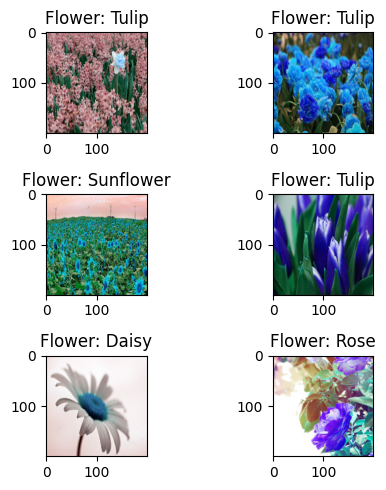

In [ ]:
fig,ax=plt.subplots(3,2)
fig.set_size_inches(5,5)
for i in range(3):
    for j in range (2):
        l=rn.randint(0,len(Z))
        ax[i,j].imshow(X[l])
        ax[i,j].set_title('Flower: '+Z[l])

plt.tight_layout()

## Preprocessing

### 1. Reshape:
- Reshape is a process of changing the shape of an array or tensor without altering its data.
- For example, the Flowers dataset contains images with a shape of (320, 240), but neural networks often require a shape of (224, 224, 3)

In [ ]:
# We did that above

In [ ]:
Y = np.array(Z)
X = np.array(X)

### 2.Label Encoding the label array & then One Hot Encoding

EX:
  - Daisy -> 0
  - Rose -> 1
  .
  .
  .




In [ ]:
le=LabelEncoder()
Y=le.fit_transform(Y.reshape(-1, 1)) # To make sure it's 1D array
Y=to_categorical(Y,5)

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


### 3. Normalization.
- Normalization is a preprocessing step in which we scale the input data to a specific range, often [0, 1] or [-1, 1]. This step is crucial for neural networks because it helps in speeding up the convergence during training and leads to better performance.

- For image data, normalization typically involves dividing pixel values by 255 (the maximum value for a pixel in an 8-bit). This scales the pixel values, originally in the range [0, 255], to [0, 1].

- So we normalize the flower images by dividing the pixel values by 255.


In [ ]:
# Normalize the data
# X = X.astype(np.float16) / 255.0
X = X / 255.0
print("x_train shape: ",X.shape)

x_train shape:  (4317, 200, 200, 3)


In [ ]:
# clean garbage collection
import gc
gc.collect()

0

## Splitting the Data into Train and Validation

- We split the data into train and test sets.
- validation size is 25%.
- train size is 75%.


In [ ]:
# Split the train and the validation set for the fitting

from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.25,random_state=42)
print("x_train shape",X_train.shape)
print("x_test shape",X_test.shape)
print("y_train shape",Y_train.shape)
print("y_test shape",Y_test.shape)

x_train shape (3237, 200, 200, 3)
x_test shape (1080, 200, 200, 3)
y_train shape (3237, 5)
y_test shape (1080, 5)


# Understanding Convolutional Neural Networks (CNNs)
CNNs are a class of deep neural networks, most commonly applied to analyzing visual imagery. They are designed to automatically and adaptively learn spatial hierarchies of features from input images.

## CNN Architecture
CNN architecture consists of:
- **Convolutional Layers**: Apply filters to the input image, extracting features.
- **Pooling Layers**: Downsample the dimensions, reducing the number of parameters.
- **Fully Connected Layers**: Connect every neuron in one layer to every neuron in another layer.


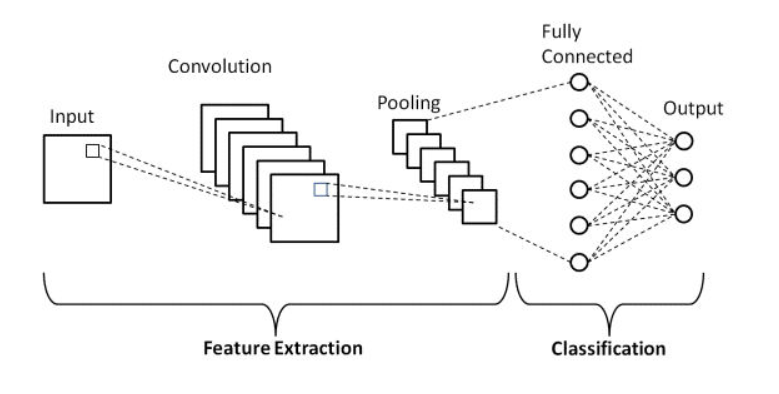

## Pooling Layer
Pooling layers are used in CNNs to reduce the spatial dimensions (width and height) of the input volume. This reduction helps in decreasing the number of parameters and computations in the network, which also helps in controlling overfitting.

### Types of Pooling:
- **Max Pooling**: Selects the maximum value from the region of the feature map covered by the filter.
- **Average Pooling**: Computes the average of all the values in the region covered by the filter.

Pooling is usually applied after a convolutional layer and helps retain important information while reducing the dimensions.


![Illustration-of-Max-Pooling-and-Average-Pooling-Figure-2-above-shows-an-example-of-max.png](attachment:2c38fb26-c36c-40f2-9faa-4a00b06e9bcc.png)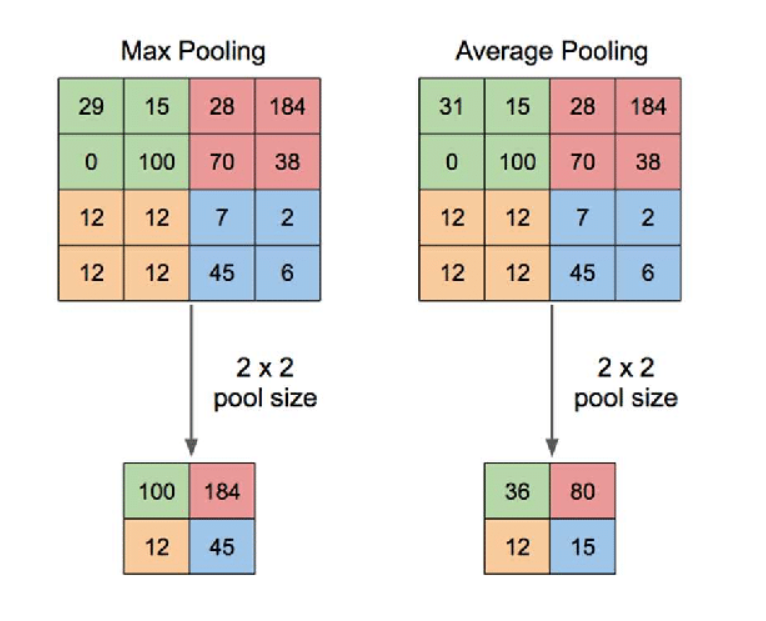

## Padding
Padding refers to the process of adding extra pixels around the border of the input image or feature map. The primary reasons for padding are:

- **Preserve Spatial Dimensions**: Padding allows the network to preserve the spatial dimensions of the input when applying convolutional layers.
- **Avoid Information Loss**: Without padding, every convolution operation reduces the size of the feature map, which might lead to the loss of important information at the edges.

### Same Padding:
Same Padding is added to ensure that the output feature map has the same spatial dimensions as the input.


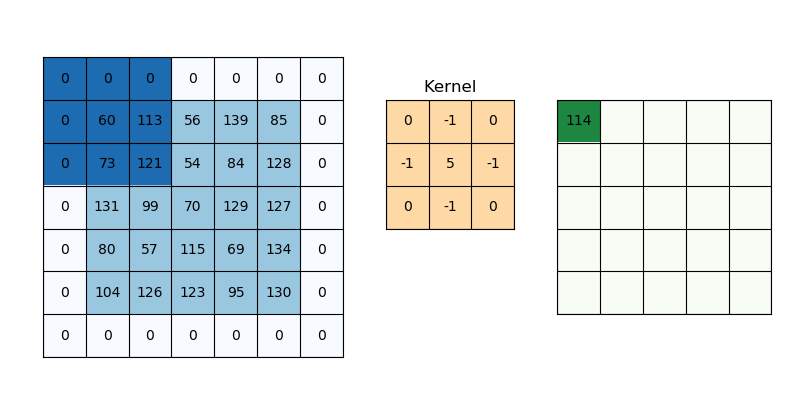

### After having convolution layer we use ReLU to break up linearity. Increase nonlinearity. Because images are non linear.


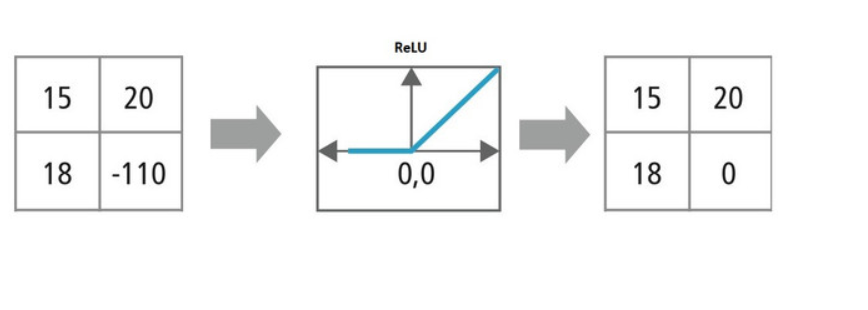

### Flattening
Flattening is the process of converting a multidimensional input (like a feature map) into a one-dimensional vector. This step is necessary before passing the data into fully connected layers, which expect input in a flat format.

In a CNN, after the convolutional and pooling layers have extracted features and reduced the spatial dimensions, flattening is used to prepare the data for the final classification by the fully connected layers.

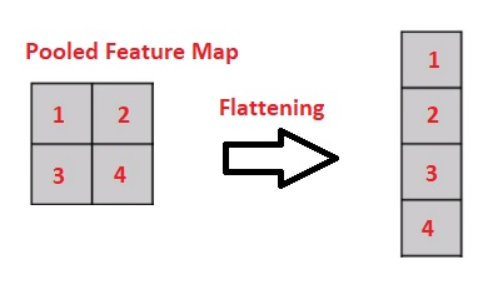

## Finally the fully connected NN
![50492simple_neural_network_header.jpg](attachment:72269aba-ae7d-4d6e-8f99-cf1d6368fe08.jpg)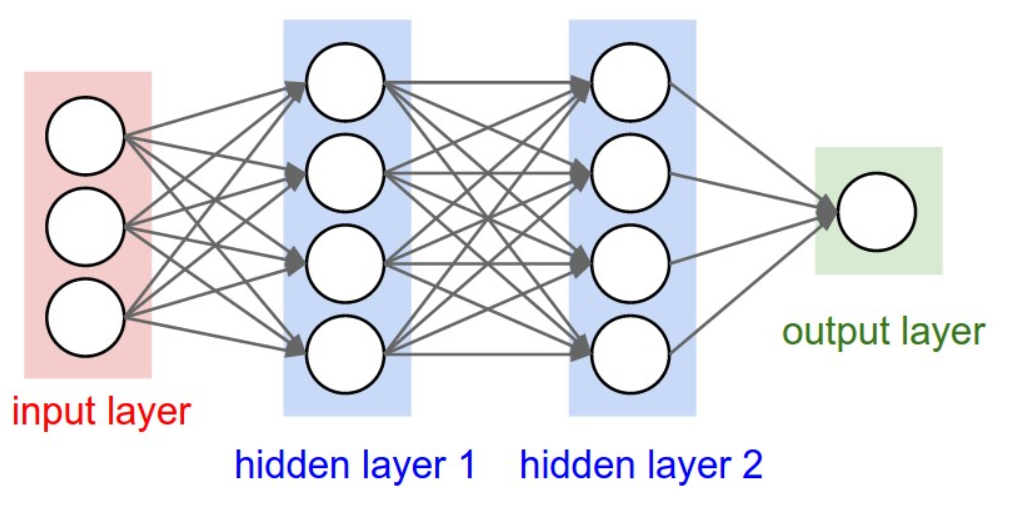

(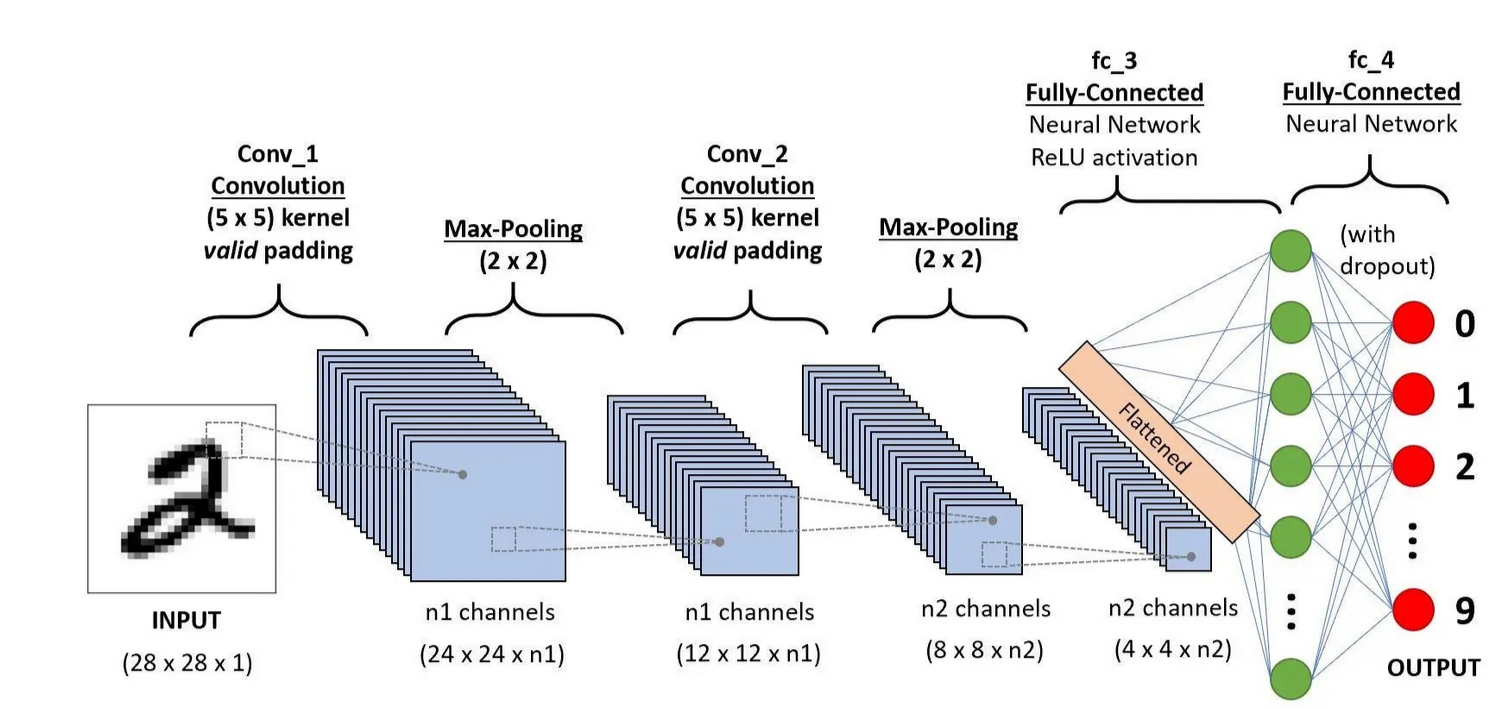)

## Lets build our first CNN !!!

### First we need to import these libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import keras
from keras.models import Sequential
from keras.layers import Conv2D, Lambda, MaxPooling2D # convolution layers
from keras.layers import Dense, Dropout, Flatten # core layers
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [ ]:
model=Sequential()

model.add(Conv2D(filters=64, kernel_size = (5,5) , padding = 'Same', activation="relu", input_shape=(200,200,3)))
model.add(MaxPooling2D(pool_size=(2,2)))


model.add(Conv2D(filters=128, kernel_size = (3,3), padding = 'Same', activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))

model.add(Conv2D(filters=256, kernel_size = (3,3), padding = 'Same', activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))

model.add(Conv2D(filters=256, kernel_size = (3,3), padding = 'Same', activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))

model.add(Flatten())
model.add(Dense(512,activation="relu"))

model.add(Dense(5,activation="softmax"))

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 200, 200, 64)        │           4,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 100, 100, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 100, 100, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 50, 50, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 50, 50, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 25, 25, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 25, 25, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 12, 12, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36864)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      18,874,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │           2,565 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,841,413 (75.69 MB)

 Trainable params: 19,841,413 (75.69 MB)

 Non-trainable params: 0 (0.00 B)

## Before we run the model
### Let's talk about augmentation


### Data Augmentation

Data augmentation is a technique used to artificially expand the size and diversity of a training dataset by applying various transformations to the existing data.
### Common Augmentation Techniques:
- **Rotation**: Rotating images by a certain angle.
- **Translation**: Shifting images along the x or y axis.
- **Scaling**: Resizing images to different dimensions.
- **Flipping**: Mirroring images horizontally or vertically.
- **Cropping**: Extracting sub-regions of images.
- **Color Jittering**: Altering brightness, contrast, and saturation.

By applying these transformations, data augmentation helps create a more robust model that performs better on unseen data by reducing overfitting.


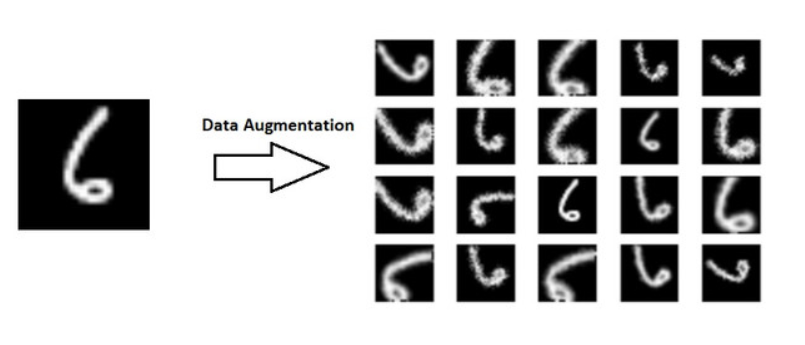

In [ ]:
# data augmentation
datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # apply ZCA whitening
        rotation_range=10,  # randomly rotate images in the range (degrees, 0 to 180)
        zoom_range = 0.1, # Randomly zoom image
        width_shift_range=0.2,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.2,  # randomly shift images vertically (fraction of total height)
        horizontal_flip=True,  # randomly flip images
        vertical_flip=False)  # randomly flip images

#datagen.fit(X_train)
train_gen = datagen.flow(X_train, Y_train, batch_size=128)
val_gen = datagen.flow(X_test, Y_test, batch_size=128)



### Epochs and Batch Size
Say you have a dataset of 10 examples (or samples). You have a batch size of 2, and you've specified you want the algorithm to run for 3 epochs. Therefore, in each epoch, you have 5 batches (10/2 = 5). Each batch gets passed through the algorithm, therefore you have 5 iterations per epoch.

In [ ]:
epochs = 10
batch_size = 128

In [ ]:
train_steps = X_train.shape[0] // batch_size
valid_steps = X_test.shape[0] // batch_size

es = keras.callbacks.EarlyStopping(
        monitor="val_acc", # metrics to monitor
        patience=10, # how many epochs before stop
        verbose=1,
        mode="max", # we need the maximum accuracy.
        restore_best_weights=True, #
     )

rp = keras.callbacks.ReduceLROnPlateau(
        monitor="val_acc",
        factor=0.2,
        patience=3,
        verbose=1,
        mode="max",
        min_lr=0.00001,
     )

### Ok lets go back and run the model :D

In [ ]:
# Fit the model
history = model.fit(          train_gen,
                              epochs = epochs,
                              steps_per_epoch = train_steps,
                              validation_data = val_gen,
                              validation_steps = valid_steps,
                              callbacks=[es, rp])

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.2378 - loss: 2.3237 - val_accuracy: 0.4072 - val_loss: 1.3485 - learning_rate: 0.0010
Epoch 2/10


/usr/local/lib/python3.10/dist-packages/keras/src/callbacks/early_stopping.py:155: UserWarning: Early stopping conditioned on metric `val_acc` which is not available. Available metrics are: accuracy,loss,val_accuracy,val_loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.10/dist-packages/keras/src/callbacks/callback_list.py:96: UserWarning: Learning rate reduction is conditioned on metric `val_acc` which is not available. Available metrics are: accuracy,loss,val_accuracy,val_loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - accuracy: 0.3906 - loss: 1.3579 - val_accuracy: 0.3750 - val_loss: 1.4883 - learning_rate: 0.0010
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.4252 - loss: 1.3328 - val_accuracy: 0.4678 - val_loss: 1.1899 - learning_rate: 0.0010
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4844 - loss: 1.2033 - val_accuracy: 0.5536 - val_loss: 1.0940 - learning_rate: 0.0010
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.4813 - loss: 1.1963 - val_accuracy: 0.5938 - val_loss: 1.0962 - learning_rate: 0.0010
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4324 - loss: 1.2435 - val_accuracy: 0.5893 - val_loss: 1.0511 - learning_rate: 0.0010
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.5455 - loss: 1.1000 - val_accuracy: 0.5732 - val_loss: 1.0669 - learning_rate: 0.0010
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 438ms/step - accuracy: 0.5781 - loss: 1.0091 - val_accuracy: 0.500

In [ ]:
# To save the model and the weight of it
import tensorflow as tf
#model.save('/content/drive/MyDrive/scratch_model.keras')
#model.save_weights('/content/drive/MyDrive/scratch_model_weights.weights.h5')
#To load the mode and weight
model = tf.keras.models.load_model('/content/drive/MyDrive/scratch_model.keras')
model.load_weights('/content/drive/MyDrive/scratch_model_weights.weights.h5')

In [ ]:
#Clear gpu's memory

from tensorflow.keras import backend as K
K.clear_session()

### Plot the loss and accuracy curves for training and validation

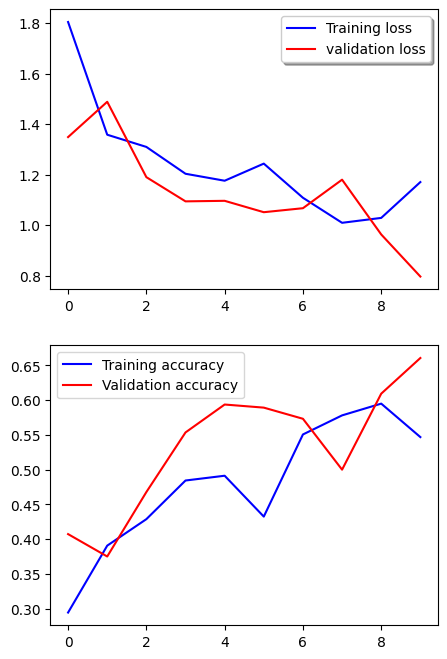

In [ ]:
fig, ax = plt.subplots(2,1, figsize=(5, 8))
ax[0].plot(history.history['loss'], color='b', label="Training loss")
ax[0].plot(history.history['val_loss'], color='r', label="validation loss",axes =ax[0])
legend = ax[0].legend(loc='best', shadow=True)

ax[1].plot(history.history['accuracy'], color='b', label="Training accuracy")
ax[1].plot(history.history['val_accuracy'], color='r',label="Validation accuracy")
legend = ax[1].legend()

### Confussion Matrix and Prediction

34/34 ━━━━━━━━━━━━━━━━━━━━ 163s 5s/step
['Rose' 'Tulip' 'Tulip' ... 'Sunflower' 'Sunflower' 'Tulip']
['Rose' 'Tulip' 'Tulip' ... 'Sunflower' 'Sunflower' 'Rose']


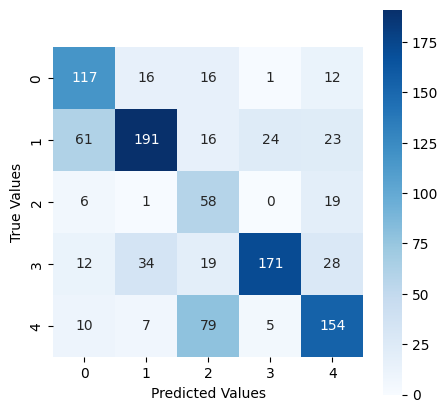

In [ ]:
# Predict class probabilities
y_pred = model.predict(X_test)
# Convert predictions classes to one hot vectors and 1D array
Y_pred_classes = le.inverse_transform(np.argmax(y_pred,axis = 1))
print(Y_pred_classes)
Y_true = le.inverse_transform(np.argmax(Y_test,axis = 1))
print(Y_true)
# Plot Confusion matrix
fig = plt.figure(figsize=(5, 5)) # Set Figure
mat = confusion_matrix(Y_true, Y_pred_classes) # Confusion matrix
sns.heatmap(mat.T, square=True, annot=True, cbar=True, cmap=plt.cm.Blues, fmt='.0f')
plt.xlabel('Predicted Values')
plt.ylabel('True Values');
plt.show();

## Visualizing Predictons on the Validation Set

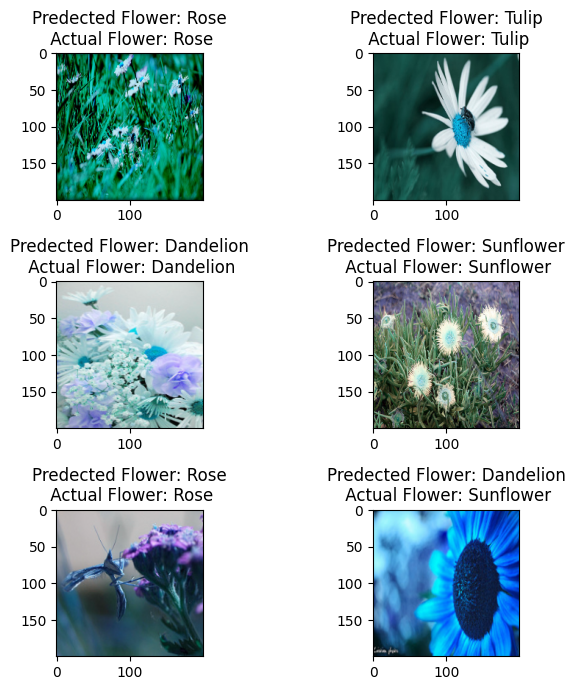

In [ ]:
fig,ax=plt.subplots(3,2)
fig.set_size_inches(7,7)
for i in range(3):
    for j in range (2):
        l=rn.randint(0,len(y_pred))
        ax[i,j].imshow(X[l])
        ax[i,j].set_title('Predected Flower: '+Y_pred_classes[l] + '\n Actual Flower: '+Y_true[l])

plt.tight_layout()

## Architectures


### VGG (Visual Geometry Group)
VGG is a convolutional neural network (CNN) architecture known for its simplicity and depth. VGG made a significant impact in the field of image classification due to its effective design and performance in the ImageNet competition.

#### Architecture Details

1. Convolutional Layers:

    Filter Size: VGG uses very small convolutional filters, specifically 3x3 kernels, which are applied across the entire image.
    Strides and Padding: Convolutions are performed with a stride of 1, and padding is used to maintain spatial dimensions.

2. Max-Pooling Layers:

    Pooling Size: Max-pooling layers with a 2x2 filter and a stride of 2 are used to downsample the feature maps, reducing their spatial dimensions while retaining important features.

3. Fully Connected Layers:

    Dense Layers: After several convolutional and pooling layers, the output is flattened and fed into fully connected layers. VGG models typically use three dense layers at the end, with the first two layers having 4096 units each, and the final layer outputting the class scores.

4. Activation Functions:

    ReLU Activation: The Rectified Linear Unit (ReLU) activation function is used after each convolutional and fully connected layer to introduce non-linearity into the model.

5. Dropout:

    Regularization: Dropout is applied to the fully connected layers to prevent overfitting by randomly dropping units during training.

#### VGG Variants
VGG16: The original VGG model with 16 weight layers (13 convolutional layers and 3 fully connected layers).

VGG19: An extension of VGG16 with 19 weight layers (16 convolutional layers and 3 fully connected layers).

The typical architecture of VGG16 is structured as follows:
1. Convolutional Block 1:
  - 2 Convolutional Layers (64 filters, 3x3 kernel)
  - 1 Max-Pooling Layer (2x2)

2. Convolutional Block 2:
  - 2 Convolutional Layers (128 filters, 3x3 kernel)
  - 1 Max-Pooling Layer (2x2)

3. Convolutional Block 3:
  - 3 Convolutional Layers (256 filters, 3x3 kernel)
  - 1 Max-Pooling Layer (2x2)

4. Convolutional Block 4:
  - 3 Convolutional Layers (512 filters, 3x3 kernel)
  - 1 Max-Pooling Layer (2x2)

5. Convolutional Block 5:
  - 3 Convolutional Layers (512 filters, 3x3 kernel)
  - 1 Max-Pooling Layer (2x2)

6. Fully Connected Layers:
  - 2 Dense Layers (4096 units each)
  - 1 Output Layer (number of classes)

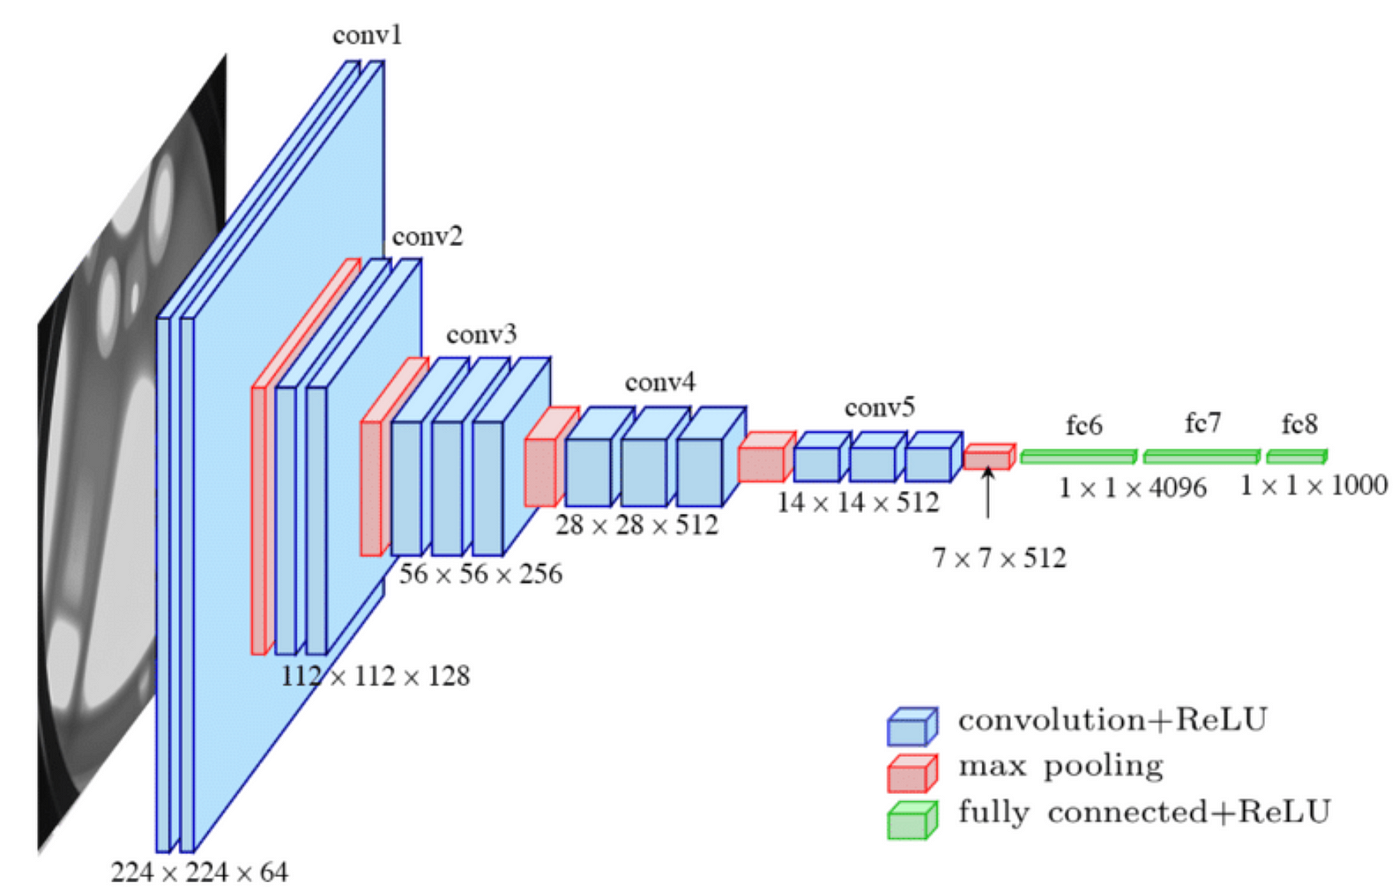

## Let's create VGG16 Model !!!

### Implement it from scratch (We'll not use it)

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def create_vgg16_model(input_shape=(220, 220, 3), num_classes=5):
    model = Sequential()

    # Convolutional Block 1
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=input_shape))
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2), strides=(2, 2)))

    # Convolutional Block 2
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2), strides=(2, 2)))

    # Convolutional Block 3
    model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2), strides=(2, 2)))

    # Convolutional Block 4
    model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2), strides=(2, 2)))

    # Convolutional Block 5
    model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2), strides=(2, 2)))

    # Flatten and Fully Connected Layers
    model.add(Flatten())
    model.add(Dense(4096, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(4096, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    return model

# Create a VGG16 model
input_shape = (224, 224, 3)  # Example input shape (height, width, channels)
num_classes = 1000  # Example number of classes
model = create_vgg16_model(input_shape=input_shape, num_classes=num_classes)

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Print model summary
model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 224, 224, 64)      1792      
                                                                 
 conv2d_5 (Conv2D)           (None, 224, 224, 64)      36928     
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 112, 112, 64)      0         
 g2D)                                                            
                                                                 
 conv2d_6 (Conv2D)           (None, 112, 112, 128)     73856     
                                                                 
 conv2d_7 (Conv2D)           (None, 112, 112, 128)     147584    
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 56, 56, 128)       0         
 g2D)                                                 

## Prebuild Function

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Set include_top=True to include the fully connected layers at the top of the network
# Set weights='imagenet' to load weights pre-trained on ImageNet
vgg16_base = VGG16(include_top=False, weights='imagenet', input_shape=(200, 200, 3))


# Add custom layers on top of the VGG16 base model
x = Flatten()(vgg16_base.output)  # Flatten the output from the convolutional layers
x = Dense(1024, activation='relu')(x)  # Add a fully connected layer with 512 units
x = BatchNormalization()(x)
x = Dense(5, activation='softmax')(x)  # Final layer for classification

# Create the final model
vgg16_model = Model(inputs=vgg16_base.input, outputs=x)

vgg16_model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
# Print model summary
vgg16_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 200, 200, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 200, 200, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 200, 200, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 100, 100, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 100, 100, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 100, 100, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 50, 50, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 50, 50, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 50, 50, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 50, 50, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 25, 25, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 25, 25, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 25, 25, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 25, 25, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 12, 12, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 12, 12, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 12, 12, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 12, 12, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 6, 6, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 18432)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1024)                │      18,875,392 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 33,599,301 (128.17 MB)

 Trainable params: 33,597,253 (128.16 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [ ]:
# Train the model using the data generators
history = vgg16_model.fit(
    train_gen,
    steps_per_epoch = train_steps,
    epochs=30,
    validation_data=val_gen,
    validation_steps = valid_steps
)

Epoch 1/30


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


25/25 ━━━━━━━━━━━━━━━━━━━━ 214s 4s/step - accuracy: 0.5719 - loss: 1.1594 - val_accuracy: 0.6797 - val_loss: 0.8101
Epoch 2/30
 1/25 ━━━━━━━━━━━━━━━━━━━━ 17:03 43s/step - accuracy: 0.6757 - loss: 0.7716

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


25/25 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.6757 - loss: 0.7716 - val_accuracy: 0.7143 - val_loss: 0.7062
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.7965 - loss: 0.5509 - val_accuracy: 0.6738 - val_loss: 0.8500
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9062 - loss: 0.2831 - val_accuracy: 0.7321 - val_loss: 0.8499
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 86s 3s/step - accuracy: 0.8507 - loss: 0.4000 - val_accuracy: 0.7549 - val_loss: 0.6025
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.8672 - loss: 0.3412 - val_accuracy: 0.7857 - val_loss: 0.5934
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.8990 - loss: 0.2619 - val_accuracy: 0.8203 - val_loss: 0.5045
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8594 - loss: 0.3542 - val_accuracy: 0.7500 - val_loss: 0.5592
Epoch 9/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.9157 - loss: 0.2220 - val_accuracy: 0.8135 - val_loss: 0.5512


In [ ]:
# To save the model and the weight of it
vgg16_model.save('/content/drive/MyDrive/vgg16_model.keras')
vgg16_model.save_weights('/content/drive/MyDrive/vgg16_model_weights.weights.h5')
#To load the mode and weight
vgg16_model = tf.keras.models.load_model('/content/drive/MyDrive/vgg16_model.keras')
vgg16_model.load_weights('/content/drive/MyDrive/vgg16_model_weights.weights.h5')

### Confussion Matrix and Prediction

34/34 ━━━━━━━━━━━━━━━━━━━━ 630s 18s/step
['Rose' 'Tulip' 'Tulip' ... 'Sunflower' 'Sunflower' 'Rose']
['Rose' 'Tulip' 'Tulip' ... 'Sunflower' 'Sunflower' 'Rose']


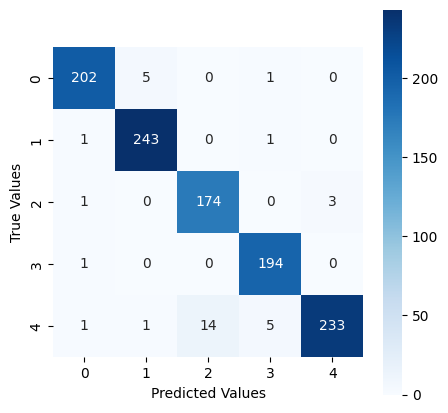

In [ ]:
# Predict class probabilities
y_pred = vgg16_model.predict(X_test)
# Convert predictions classes to one hot vectors and 1D array
Y_pred_classes = le.inverse_transform(np.argmax(y_pred,axis = 1))
print(Y_pred_classes)
Y_true = le.inverse_transform(np.argmax(Y_test,axis = 1))
print(Y_true)
# Plot Confusion matrix
fig = plt.figure(figsize=(5, 5)) # Set Figure
mat = confusion_matrix(Y_true, Y_pred_classes) # Confusion matrix
sns.heatmap(mat.T, square=True, annot=True, cbar=True, cmap=plt.cm.Blues, fmt='.0f')
plt.xlabel('Predicted Values')
plt.ylabel('True Values');
plt.show();

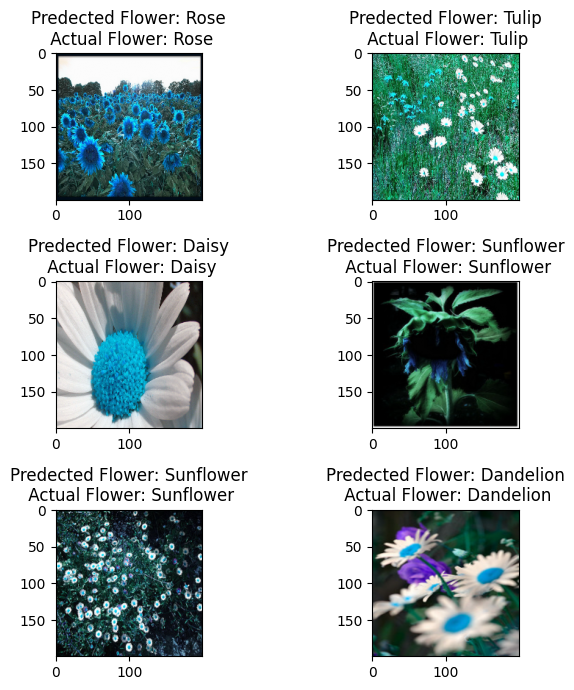

In [ ]:
fig,ax=plt.subplots(3,2)
fig.set_size_inches(7,7)
for i in range(3):
    for j in range (2):
        l=rn.randint(0,len(y_pred))
        ax[i,j].imshow(X[l])
        ax[i,j].set_title('Predected Flower: '+Y_pred_classes[l] + '\n Actual Flower: '+Y_true[l])

plt.tight_layout()